# 1. Objective

In this notebook, I evaluate the robustness of the Random Forest trading strategy developed in the previous step. I test whether the observed performance is stable across different time periods, resilient to feature reduction, and consistent under alternative threshold settings. The goal is to determine whether the strategy reflects a genuine signal or is driven by overfitting and noise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.data_loader import split_features_target
from src.data_loader import time_based_split
from src.data_loader import get_benchmark_returns
from src.backtest import generate_positions_from_proba
from src.backtest import strategy_returns_from_positions
from src.backtest import cumulative_returns
from src.backtest import evaluate_strategy

# 2. Load preprocessed data

In [2]:
project_root = Path.cwd().parent
nb02_path = project_root / "data" / "processed" / "notebook_02_data_prep"
nb05_path = project_root / "data" / "processed" / "notebook_05_model_outputs"
nb09_path = project_root / "data" / "processed" / "notebook_09_random_forest_model"
rf_results = pd.read_csv(nb09_path / "random_forest_results.csv", index_col=0)
rf_feature_importance = pd.read_csv(nb09_path / "random_forest_feature_importance.csv", index_col=0)
rf_thresholds = pd.read_csv(nb09_path / "rf_thresholds.csv", index_col=0)
ML_dataset = pd.read_csv(nb05_path / "ML_dataset.csv", index_col=0)
clean_close_prices = pd.read_csv(nb02_path / "clean_close_prices.csv", index_col=0)
rf_results

,Random Forest,Benchmark
Annualized Return,0.230930,0.118927
Annualized Volatility,0.142381,0.173347
Sharpe Ratio,1.621920,0.686062
Max Drawdown,-0.111430,-0.187552
Hit Rate,0.373391,0.561881
Exposure Rate,0.401985,NaN
Turnover,0.382134,NaN


# 3. Define features/ target and split based on time

In [3]:
X, y = split_features_target (ML_dataset)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
X_train, X_test, y_train, y_test = time_based_split(X, y)
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training targets:", len(y_train))
print("Testing targets:", len(y_test))

Feature shape: (2016, 310)
Target shape: (2016,)

Training samples: 1612
Testing samples: 404
Training targets: 1612
Testing targets: 404


# 4. Benchmark Returns (Aligned to Test Period)

In [4]:
benchmark_returns = get_benchmark_returns(price_df=clean_close_prices,
                                          tickers="SPY",
                                          index=X_test.index)
benckmark_cum_returns = cumulative_returns(benchmark_returns)

# Section 1: Subperiod validation

## 5. Recreate baseline Random Forest model

In [5]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]
rf_prob_series = pd.Series(rf_prob, index=X_test.index, name="rf_prob_series")

## 6. Recreate baseline positions and returns

In [6]:
rf_position, long_threshold, short_threshold = generate_positions_from_proba(probabilities=rf_prob_series,
                                                                             index=X_test.index,
                                                                             upper_quantile=0.8,
                                                                             lower_quantile=0.2)
rf_gross_returns = strategy_returns_from_positions(positions = rf_position,
                                                   returns = benchmark_returns,
                                                   lag=1)
rf_net_returns = strategy_returns_from_positions(positions = rf_position,
                                                 returns = benchmark_returns,
                                                 lag=1,
                                                 cost_per_trade=0.0005)
rf_cum_returns = cumulative_returns(rf_net_returns)
rf_baseline_results = pd.DataFrame({"Random Forest": rf_cum_returns, "Benchmark": benckmark_cum_returns})
rf_baseline_results.head(10)

,Random Forest,Benchmark
Date,,
2024-08-26,NaN,0.997616
2024-08-27,1.000000,0.998986
2024-08-28,0.993695,0.993187
2024-08-29,0.993784,0.993275
2024-08-30,0.993287,1.002757
2024-09-03,0.993287,0.982122
2024-09-04,0.994823,0.980111
2024-09-05,0.994326,0.977727
2024-09-06,0.994326,0.961272


## 7. Split the test period into early and late subperiods

In [7]:
midpoint = len(rf_net_returns) // 2
H1_returns = rf_net_returns.iloc[:midpoint]
H2_returns = rf_net_returns.iloc[midpoint:]
H1_positions = rf_position.loc[H1_returns.index]
H2_positions = rf_position.loc[H2_returns.index]
H1_benchmark = benchmark_returns.loc[H1_returns.index]
H2_benchmark = benchmark_returns.loc[H2_returns.index]
print("1st Half subperiod length:", len(H1_returns))
print("2nd Half subperiod length:", len(H2_returns))


1st Half subperiod length: 201
2nd Half subperiod length: 202


## 8. Evaluate subperiod signal stability

In [8]:
H1_summary = evaluate_strategy(returns=H1_returns, positions=H1_positions)
H2_summary = evaluate_strategy(returns=H2_returns, positions=H2_positions)
H1_benchmark_summary = evaluate_strategy(returns=H1_benchmark)
H2_benchmark_summary = evaluate_strategy(returns=H2_benchmark)
subperiod_results = pd.DataFrame({"RF Early": H1_summary, "RF Late": H2_summary,
                                  "Benchmark Early": H1_benchmark_summary, "Benchmark Late": H2_benchmark_summary})
subperiod_results

,RF Early,RF Late,Benchmark Early,Benchmark Late
Annualized Return,0.677991,-0.095636,0.107535,0.134380
Annualized Volatility,0.180698,0.085231,0.215143,0.119086
Sharpe Ratio,3.752060,-1.122082,0.499831,1.128433
Max Drawdown,-0.049675,-0.111430,-0.187552,-0.088850
Hit Rate,0.371901,0.375000,0.582090,0.544554
Exposure Rate,0.398010,0.405941,NaN,NaN
Turnover,0.452736,0.306931,NaN,NaN


## 9. Plot H1 and H2 subperiod cumulative returns

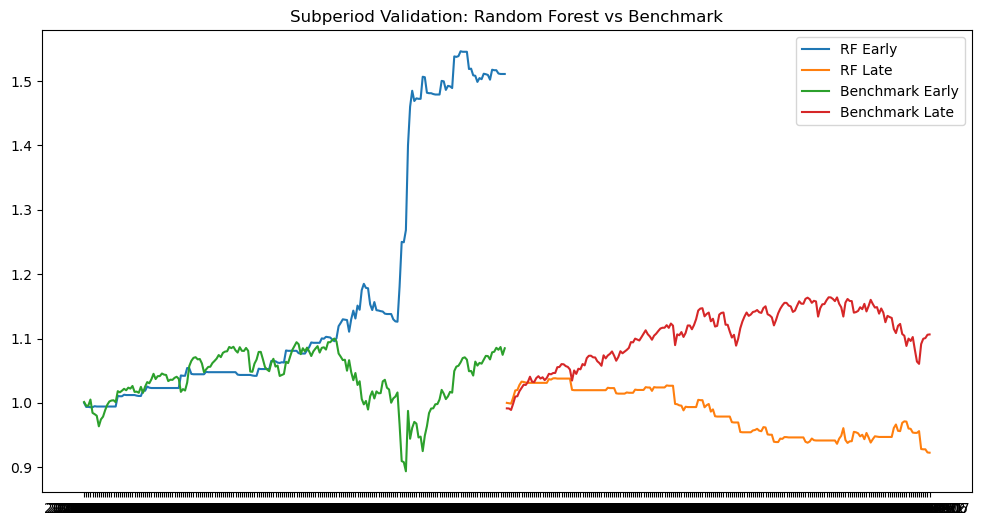

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns(H1_returns), label="RF Early")
plt.plot(cumulative_returns(H2_returns), label="RF Late")
plt.plot(cumulative_returns(H1_benchmark), label="Benchmark Early")
plt.plot(cumulative_returns(H2_benchmark), label="Benchmark Late")
plt.title("Subperiod Validation: Random Forest vs Benchmark")
plt.legend()
plt.show()

# Section 2: Pruned model test

## 10. Choose top features

In [10]:
top = 30
top_features = rf_feature_importance.head(top).index.tolist()
X_train_top = X_train[top_features].copy()
X_test_top = X_test[top_features].copy()
print("Original feature count:", X_train.shape[1])
print("Reduced feature count:", X_train_top.shape[1])

Original feature count: 310
Reduced feature count: 30


## 11. Retrain pruned Random Forest model

In [11]:
rf_model_pruned = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42)
rf_model_pruned.fit(X_train_top, y_train)
rf_pruned_pred = rf_model_pruned.predict(X_test_top)
rf_pruned_prob = rf_model_pruned.predict_proba(X_test_top)[:,1]
rf_pruned_prob_series = pd.Series(rf_pruned_prob, index=X_test_top.index, name="rf_pruned_prob_series")

## 12. Regenerate pruned positions and returns

In [12]:
rf_pruned_position, pruned_long_threshold, pruned_short_threshold = generate_positions_from_proba(probabilities=rf_pruned_prob_series,
                                                                                                  index=X_test_top.index,
                                                                                                  upper_quantile=0.8,
                                                                                                  lower_quantile=0.2)
rf_pruned_gross_returns = strategy_returns_from_positions(positions = rf_pruned_position,
                                                          returns = benchmark_returns,
                                                          lag=1)
rf_pruned_net_returns = strategy_returns_from_positions(positions = rf_pruned_position,
                                                        returns = benchmark_returns,
                                                        lag=1,
                                                        cost_per_trade=0.0005)
rf_pruned_cum_returns = cumulative_returns(rf_pruned_net_returns)
rf_pruned_results = pd.DataFrame({"Random Forest": rf_pruned_cum_returns, "Benchmark": benckmark_cum_returns})

## 13. Compare RF vs pruned RF returns

In [13]:
rf_summary = evaluate_strategy(returns=rf_net_returns, positions=rf_position)
pruned_rf_summary = evaluate_strategy(returns=rf_pruned_net_returns, positions=rf_pruned_position)
benchmark_summary = evaluate_strategy(returns=benchmark_returns)
pruning_results = pd.DataFrame({"Baseline RF": rf_summary, "Pruned RF": pruned_rf_summary, "Benchmark": benchmark_summary})
pruning_results

,Baseline RF,Pruned RF,Benchmark
Annualized Return,0.230930,0.214146,0.118927
Annualized Volatility,0.142381,0.135139,0.173347
Sharpe Ratio,1.621917,1.584636,0.686061
Max Drawdown,-0.111430,-0.078725,-0.187552
Hit Rate,0.373391,0.386957,0.561881
Exposure Rate,0.401985,0.401985,NaN
Turnover,0.382134,0.382134,NaN


# Section 3: Pruned RF Model subperiod validation

## 14. Split the test period into early and late subperiods

In [14]:
midpoint_pruned = len(rf_pruned_net_returns) // 2
H1_pruned_returns = rf_pruned_net_returns.iloc[:midpoint_pruned]
H2_pruned_returns = rf_pruned_net_returns.iloc[midpoint_pruned:]
H1_pruned_positions = rf_pruned_position.loc[H1_pruned_returns.index]
H2_pruned_positions = rf_pruned_position.loc[H2_pruned_returns.index]
H1_pruned_benchmark = benchmark_returns.loc[H1_pruned_returns.index]
H2_pruned_benchmark = benchmark_returns.loc[H2_pruned_returns.index]
print("1st Half pruned subperiod length:", len(H1_pruned_returns))
print("2nd Half pruned subperiod length:", len(H2_pruned_returns))

1st Half pruned subperiod length: 201
2nd Half pruned subperiod length: 202


## 15. Evaluate pruned RF subperiod signal stability

In [15]:
H1_pruned_summary = evaluate_strategy(returns=H1_pruned_returns, positions=H1_pruned_positions)
H2_pruned_summary = evaluate_strategy(returns=H2_pruned_returns, positions=H2_pruned_positions)
H1_pruned_benchmark_summary = evaluate_strategy(returns=H1_pruned_benchmark)
H2_pruned_benchmark_summary = evaluate_strategy(returns=H2_pruned_benchmark)
pruned_subperiod_results = pd.DataFrame({"Pruned RF Early": H1_pruned_summary, "Pruned RF Late": H2_pruned_summary,
                                         "Pruned Benchmark Early": H1_pruned_benchmark_summary, "Pruned Benchmark Late": H2_pruned_benchmark_summary})
pruned_subperiod_results

,Pruned RF Early,Pruned RF Late,Pruned Benchmark Early,Pruned Benchmark Late
Annualized Return,0.580166,-0.065873,0.107535,0.134380
Annualized Volatility,0.175950,0.071724,0.215143,0.119086
Sharpe Ratio,3.297333,-0.918429,0.499831,1.128433
Max Drawdown,-0.035024,-0.078725,-0.187552,-0.088850
Hit Rate,0.434426,0.333333,0.582090,0.544554
Exposure Rate,0.437811,0.366337,NaN,NaN
Turnover,0.398010,0.361386,NaN,NaN


## 16. Threshold sensitivity test

In [16]:
quantile_pairs = [(0.70, 0.30), (0.80, 0.20), (0.90, 0.10)]
pruned_threshold_results = []
for upper_q, lower_q in quantile_pairs:
    pos, up_th, low_th = generate_positions_from_proba(probabilities=rf_pruned_prob_series, index=X_test_top.index,
                                                       upper_quantile=upper_q, lower_quantile=lower_q)
    net_ret = strategy_returns_from_positions(positions=pos, returns=benchmark_returns, lag=1, cost_per_trade=0.0005)
    summary = evaluate_strategy(returns=net_ret, positions=pos)
    summary["Upper Quantile"] = upper_q
    summary["Lower Quantile"] = lower_q
    pruned_threshold_results.append(summary)
pruned_threshold_results = pd.DataFrame(pruned_threshold_results)
pruned_threshold_results

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Rate,Exposure Rate,Turnover,Upper Quantile,Lower Quantile
0,0.166185,0.154126,1.078244,-0.100934,0.377358,0.598015,0.498759,0.7,0.3
1,0.214146,0.135139,1.584636,-0.078725,0.386957,0.401985,0.382134,0.8,0.2
2,0.226515,0.120331,1.882432,-0.061967,0.393443,0.203474,0.218362,0.9,0.1


## 17. Plot H1 and H2 pruned subperiod cumulative returns

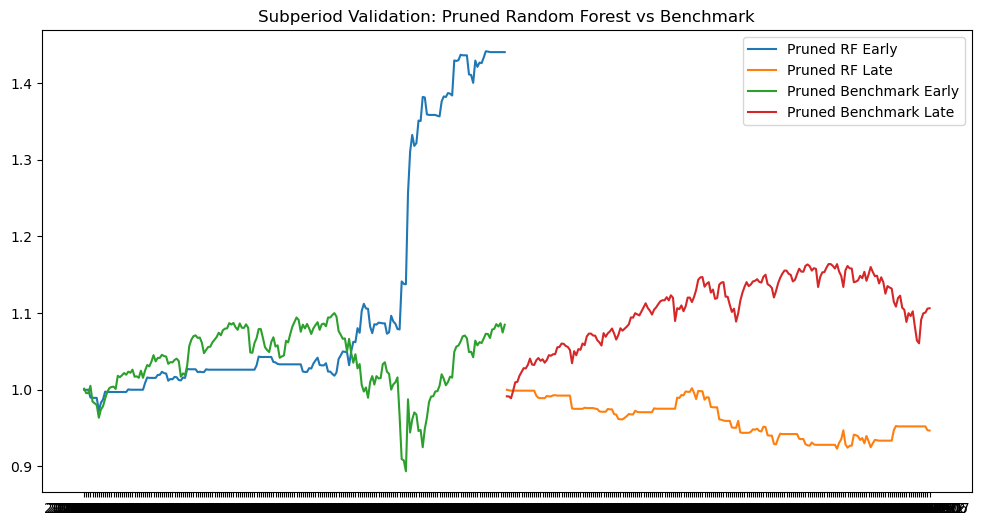

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns(H1_pruned_returns), label="Pruned RF Early")
plt.plot(cumulative_returns(H2_pruned_returns), label="Pruned RF Late")
plt.plot(cumulative_returns(H1_pruned_benchmark), label="Pruned Benchmark Early")
plt.plot(cumulative_returns(H2_pruned_benchmark), label="Pruned Benchmark Late")
plt.title("Subperiod Validation: Pruned Random Forest vs Benchmark")
plt.legend()
plt.show()

# 18. Conclusion

The Random Forest model showed initial promise, but failed under deeper validation. The strongest signal (10d_vol) did not hold up in the RF framework, and even the top 30 pruned features proved unstable across subperiods and threshold settings.

These results indicate that the current feature set lacks robustness and is likely regime-dependent.

Next step: shift focus to discovering new, more stable signals that can persist across time and varying conditions.